# DefectVision — Notebook 12
## Interactive Demo / Deployment Prototype

This notebook provides the final user-facing demonstration of DefectVision.

A user can:
1. select an RGB image,
2. run the trained segmentation model,
3. view the predicted defect mask,
4. inspect the probability map,
5. see the predicted defect percentage,
6. save the prediction result.

This notebook performs **inference only**. No training or test-set evaluation is performed here.


In [1]:

# ============================================================
# CELL 1 — SETUP
# ============================================================

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")

ROOT = Path.cwd().resolve().parent

CHECKPOINT = (
    ROOT
    / "models"
    / "checkpoints"
    / "model08_no_boundary_best.pth"
)

OUT = (
    ROOT
    / "results"
    / "demo"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)

IMAGE_SIZE = 256
THRESHOLD = 0.50

print("=" * 65)
print("DEFECTVISION — INTERACTIVE DEMO")
print("=" * 65)

print("Device:", DEVICE)
print("Checkpoint:", CHECKPOINT)
print("Checkpoint exists:", CHECKPOINT.exists())

assert CHECKPOINT.exists(), (
    "Final checkpoint not found."
)


DEFECTVISION — INTERACTIVE DEMO
Device: cpu
Checkpoint: C:\Documents\DefectVision\models\checkpoints\model08_no_boundary_best.pth
Checkpoint exists: True


In [2]:

# ============================================================
# CELL 2 — MODEL
# ============================================================

class ResidualBlock(nn.Module):

    def __init__(self, cin, cout):

        super().__init__()

        groups = min(8, cout)

        self.c1 = nn.Conv2d(
            cin, cout, 3,
            padding=1,
            bias=False
        )

        self.n1 = nn.GroupNorm(
            groups, cout
        )

        self.c2 = nn.Conv2d(
            cout, cout, 3,
            padding=1,
            bias=False
        )

        self.n2 = nn.GroupNorm(
            groups, cout
        )

        self.skip = (
            nn.Conv2d(
                cin, cout, 1,
                bias=False
            )
            if cin != cout
            else nn.Identity()
        )

    def forward(self, x):

        identity = self.skip(x)

        x = F.relu(
            self.n1(
                self.c1(x)
            )
        )

        x = self.n2(
            self.c2(x)
        )

        return F.relu(
            x + identity
        )


class MultiScaleBottleneck(nn.Module):

    def __init__(self, channels=64):

        super().__init__()

        b = channels // 4

        def branch(k, d):

            return nn.Sequential(
                nn.Conv2d(
                    channels,
                    b,
                    k,
                    padding=d if k == 3 else 0,
                    dilation=d,
                    bias=False
                ),
                nn.GroupNorm(4, b),
                nn.ReLU()
            )

        self.b1 = branch(1, 1)
        self.b2 = branch(3, 1)
        self.b3 = branch(3, 2)
        self.b4 = branch(3, 4)

        self.fuse = nn.Sequential(
            nn.Conv2d(
                channels,
                channels,
                1,
                bias=False
            ),
            nn.GroupNorm(8, channels),
            nn.ReLU()
        )

    def forward(self, x):

        y = torch.cat(
            [
                self.b1(x),
                self.b2(x),
                self.b3(x),
                self.b4(x)
            ],
            dim=1
        )

        return self.fuse(y) + x


class DefectVisionModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.e1 = ResidualBlock(3, 16)
        self.d1 = nn.Conv2d(
            16, 16, 3, 2, 1
        )

        self.e2 = ResidualBlock(16, 32)
        self.d2 = nn.Conv2d(
            32, 32, 3, 2, 1
        )

        self.e3 = ResidualBlock(32, 48)
        self.d3 = nn.Conv2d(
            48, 48, 3, 2, 1
        )

        self.e4 = ResidualBlock(48, 64)
        self.d4 = nn.Conv2d(
            64, 64, 3, 2, 1
        )

        self.b = MultiScaleBottleneck(64)

        self.x4 = ResidualBlock(128, 48)
        self.x3 = ResidualBlock(96, 32)
        self.x2 = ResidualBlock(64, 16)
        self.x1 = ResidualBlock(32, 16)

        self.ref = ResidualBlock(16, 8)

        self.out = nn.Conv2d(
            8, 1, 1
        )

    def up(self, x, target):

        return F.interpolate(
            x,
            size=target.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

    def forward(self, x):

        e1 = self.e1(x)
        e2 = self.e2(self.d1(e1))
        e3 = self.e3(self.d2(e2))
        e4 = self.e4(self.d3(e3))

        x = self.b(
            self.d4(e4)
        )

        x = self.x4(
            torch.cat(
                [self.up(x, e4), e4],
                dim=1
            )
        )

        x = self.x3(
            torch.cat(
                [self.up(x, e3), e3],
                dim=1
            )
        )

        x = self.x2(
            torch.cat(
                [self.up(x, e2), e2],
                dim=1
            )
        )

        x = self.x1(
            torch.cat(
                [self.up(x, e1), e1],
                dim=1
            )
        )

        return self.out(
            self.ref(x)
        )


model = DefectVisionModel().to(DEVICE)

checkpoint = torch.load(
    CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Model loaded successfully.")
print("Best validation epoch:", checkpoint["epoch"])
print("Best validation Dice:", checkpoint["val_dice"])


Model loaded successfully.
Best validation epoch: 8
Best validation Dice: 0.42699394


In [3]:

# ============================================================
# CELL 3 — INFERENCE ENGINE
# ============================================================

def run_defectvision(
    image_path,
    threshold=THRESHOLD
):

    image_path = Path(image_path)

    if not image_path.exists():

        raise FileNotFoundError(
            f"Image not found: {image_path}"
        )

    original = Image.open(
        image_path
    ).convert("RGB")

    original_size = original.size

    resized = original.resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        Image.Resampling.BILINEAR
    )

    rgb = np.asarray(
        resized,
        dtype=np.float32
    ) / 255.0

    mean = np.array(
        [0.485, 0.456, 0.406],
        dtype=np.float32
    ).reshape(1, 1, 3)

    std = np.array(
        [0.229, 0.224, 0.225],
        dtype=np.float32
    ).reshape(1, 1, 3)

    normalized = (
        rgb - mean
    ) / std

    tensor = torch.from_numpy(
        normalized
    ).permute(
        2, 0, 1
    ).unsqueeze(0).float()

    with torch.no_grad():

        logits = model(
            tensor.to(DEVICE)
        )

        probability = torch.sigmoid(
            logits
        )[0, 0].cpu().numpy()

    mask = (
        probability >= threshold
    ).astype(np.uint8)

    defect_pixels = int(
        mask.sum()
    )

    total_pixels = int(
        mask.size
    )

    defect_percentage = (
        defect_pixels
        / total_pixels
        * 100
    )

    if defect_pixels > 0:

        mean_probability = float(
            probability[
                mask == 1
            ].mean()
        )

    else:

        mean_probability = 0.0

    result = {

        "image_path":
            str(image_path),

        "original_width":
            original_size[0],

        "original_height":
            original_size[1],

        "threshold":
            float(threshold),

        "defect_detected":
            bool(defect_pixels > 0),

        "defect_pixels":
            defect_pixels,

        "total_pixels":
            total_pixels,

        "defect_percentage":
            float(defect_percentage),

        "mean_defect_probability":
            mean_probability,

        "max_probability":
            float(probability.max()),

        "rgb":
            rgb,

        "probability":
            probability,

        "mask":
            mask
    }

    return result


print(
    "Inference engine ready."
)


Inference engine ready.


## 4. Choose an image

For the first demonstration, use a real test image. Later, replace `IMAGE_PATH` with any compatible RGB image.


In [4]:

# ============================================================
# CELL 4 — SELECT IMAGE
# ============================================================

# First demo image
IMAGE_PATH = (
    ROOT
    / "data"
    / "raw"
    / "MVTecAD-SEG"
    / "imgs"
    / "test"
    / "1095.png"
)

print("Selected image:", IMAGE_PATH)
print("Exists:", IMAGE_PATH.exists())

assert IMAGE_PATH.exists(), (
    "Selected image does not exist."
)


Selected image: C:\Documents\DefectVision\data\raw\MVTecAD-SEG\imgs\test\1095.png
Exists: True


In [5]:

# ============================================================
# CELL 5 — RUN DEMO
# ============================================================

demo_result = run_defectvision(
    IMAGE_PATH,
    threshold=THRESHOLD
)

print("=" * 65)
print("DEFECTVISION RESULT")
print("=" * 65)

print(
    "Image:",
    Path(
        demo_result["image_path"]
    ).name
)

print(
    "Defect detected:",
    demo_result["defect_detected"]
)

print(
    "Predicted defect area:",
    f"{demo_result['defect_percentage']:.2f}%"
)

print(
    "Defect pixels:",
    demo_result["defect_pixels"]
)

print(
    "Mean defect probability:",
    f"{demo_result['mean_defect_probability']:.4f}"
)

print(
    "Maximum probability:",
    f"{demo_result['max_probability']:.4f}"
)


DEFECTVISION RESULT
Image: 1095.png
Defect detected: True
Predicted defect area: 7.62%
Defect pixels: 4991
Mean defect probability: 0.8389
Maximum probability: 0.9997


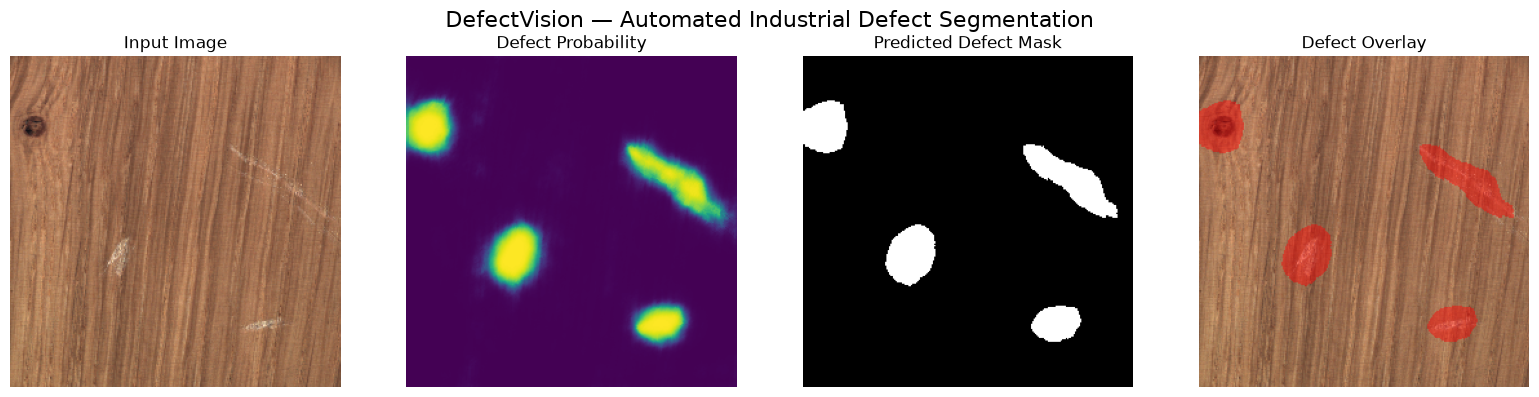

Saved demo figure: C:\Documents\DefectVision\results\demo\defectvision_demo.png


In [6]:

# ============================================================
# CELL 6 — FINAL DEMO VISUALIZATION
# ============================================================

def display_demo(result):

    rgb = result["rgb"]
    probability = result["probability"]
    mask = result["mask"]

    overlay = rgb.copy()

    defect = mask.astype(bool)

    overlay[defect] = (
        0.55 * overlay[defect]
        + 0.45 * np.array(
            [1.0, 0.0, 0.0]
        )
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4)
    )

    axes[0].imshow(rgb)
    axes[0].set_title(
        "Input Image",
        fontsize=12
    )

    axes[1].imshow(
        probability,
        cmap="viridis",
        vmin=0,
        vmax=1
    )
    axes[1].set_title(
        "Defect Probability",
        fontsize=12
    )

    axes[2].imshow(
        mask,
        cmap="gray"
    )
    axes[2].set_title(
        "Predicted Defect Mask",
        fontsize=12
    )

    axes[3].imshow(
        overlay
    )
    axes[3].set_title(
        "Defect Overlay",
        fontsize=12
    )

    for ax in axes:

        ax.axis("off")

    fig.suptitle(
        (
            "DefectVision — Automated "
            "Industrial Defect Segmentation"
        ),
        fontsize=16
    )

    plt.tight_layout()

    output_path = (
        OUT
        / "defectvision_demo.png"
    )

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved demo figure:",
        output_path
    )


display_demo(
    demo_result
)


In [7]:

# ============================================================
# CELL 7 — SAVE PREDICTION RESULTS
# ============================================================

stats = {

    "image":
        Path(
            demo_result["image_path"]
        ).name,

    "model":
        "MS-Residual U-Net",

    "loss":
        "Weighted BCE + Dice",

    "threshold":
        demo_result["threshold"],

    "defect_detected":
        demo_result["defect_detected"],

    "defect_pixels":
        demo_result["defect_pixels"],

    "total_pixels":
        demo_result["total_pixels"],

    "defect_percentage":
        demo_result["defect_percentage"],

    "mean_defect_probability":
        demo_result[
            "mean_defect_probability"
        ],

    "max_probability":
        demo_result["max_probability"]
}

with open(
    OUT / "demo_result.json",
    "w"
) as f:

    json.dump(
        stats,
        f,
        indent=2
    )


Image.fromarray(
    (
        demo_result["mask"]
        * 255
    ).astype(np.uint8)
).save(
    OUT / "predicted_mask.png"
)

print(
    "Saved:"
)

print(
    OUT / "demo_result.json"
)

print(
    OUT / "predicted_mask.png"
)


Saved:
C:\Documents\DefectVision\results\demo\demo_result.json
C:\Documents\DefectVision\results\demo\predicted_mask.png


## 8. Optional custom-image demo

Set `CUSTOM_IMAGE_PATH` to a real image on your computer and run this cell.

For example:

`C:/Documents/DefectVision/my_image.png`

The image should be an RGB image from the same general visual domain as the training data.


CUSTOM IMAGE
Defect detected: True
Predicted defect area: 7.62%
Mean defect probability: 0.8389


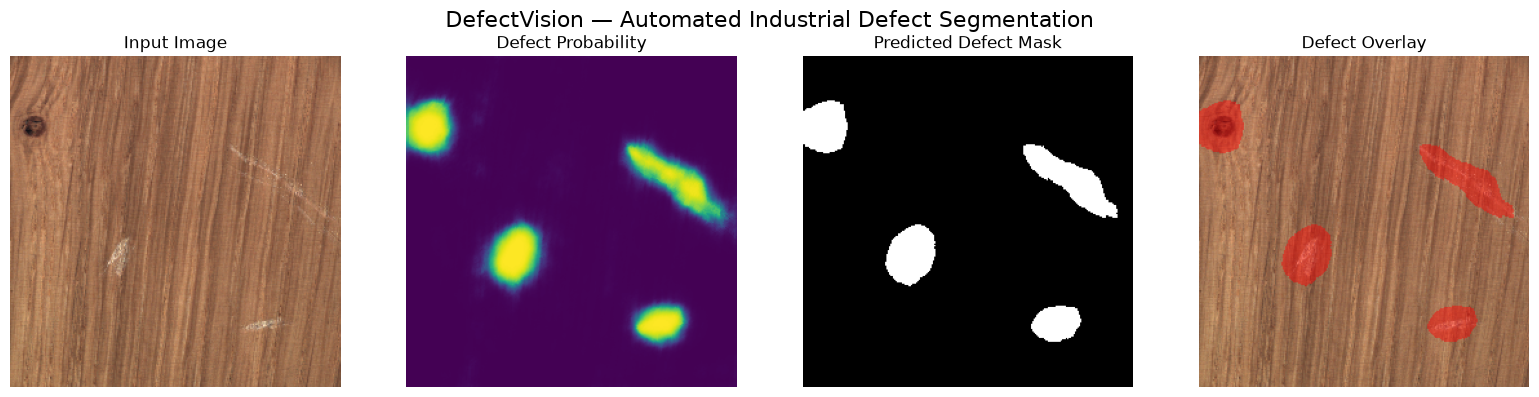

Saved demo figure: C:\Documents\DefectVision\results\demo\defectvision_demo.png


In [8]:

# ============================================================
# CELL 8 — CUSTOM IMAGE
# ============================================================

# Replace this with your own image when ready.
CUSTOM_IMAGE_PATH = IMAGE_PATH

custom_result = run_defectvision(
    CUSTOM_IMAGE_PATH,
    threshold=THRESHOLD
)

print("=" * 65)
print("CUSTOM IMAGE")
print("=" * 65)

print(
    "Defect detected:",
    custom_result["defect_detected"]
)

print(
    "Predicted defect area:",
    f"{custom_result['defect_percentage']:.2f}%"
)

print(
    "Mean defect probability:",
    f"{custom_result['mean_defect_probability']:.4f}"
)

display_demo(
    custom_result
)


In [9]:

# ============================================================
# CELL 9 — FINAL SYSTEM SUMMARY
# ============================================================

print("=" * 70)
print("DEFECTVISION DEMO COMPLETE")
print("=" * 70)

print()
print("System:")
print("  Automated industrial defect segmentation")

print()
print("Architecture:")
print("  MS-Residual U-Net")

print()
print("Training objective:")
print("  Weighted BCE + Dice")

print()
print("Held-out test performance:")
print("  Dice      : 0.3753")
print("  IoU       : 0.2758")
print("  Precision : 0.3484")
print("  Recall    : 0.6988")

print()
print("Inference provides:")
print("  ✓ Defect detection")
print("  ✓ Pixel-level defect mask")
print("  ✓ Probability map")
print("  ✓ Predicted defect area")
print("  ✓ Visual overlay")

print()
print("Demo results saved to:")
print(OUT)

print()
print("NOTEBOOK 12 COMPLETE")


DEFECTVISION DEMO COMPLETE

System:
  Automated industrial defect segmentation

Architecture:
  MS-Residual U-Net

Training objective:
  Weighted BCE + Dice

Held-out test performance:
  Dice      : 0.3753
  IoU       : 0.2758
  Precision : 0.3484
  Recall    : 0.6988

Inference provides:
  ✓ Defect detection
  ✓ Pixel-level defect mask
  ✓ Probability map
  ✓ Predicted defect area
  ✓ Visual overlay

Demo results saved to:
C:\Documents\DefectVision\results\demo

NOTEBOOK 12 COMPLETE
